In [ ]:
A university wants to analyze how students choose elective courses to identify groups of students with similar interests.
You are given a dataset where: Each student has rated several courses, Ratings range from 1 to 5 and Not all students rated all courses.
Tasks
Create a bipartite graph using NetworkX where:


One node set represents Students


The other node set represents Courses


Each edge weight represents the rating


Visualize the bipartite graph such that:


Students appear on the left


Courses appear on the right


Edge labels show the ratings


Convert the bipartite graph data into a Student–Course rating matrix suitable for machine learning.


Apply K-Means clustering on the rating matrix to divide students into 2 clusters based on their course preferences.


Visualize the bipartite graph again where:


Students are colored according to their cluster


Courses are shown in a single neutral color
Suppose courses are : AI, ML, Data Science and Cyber Security



**Question 1. Create Dataset**

In [1]:
import pandas as pd

data = {
    "Student": [
        "S1","S1","S2","S2","S3","S3",
        "S4","S4","S5","S5","S6","S6"
    ],
    "Course": [
        "AI","ML",
        "AI","Cyber Security",
        "ML","Data Science",
        "AI","Data Science",
        "Cyber Security","ML",
        "Data Science","Cyber Security"
    ],
    "Rating": [
        5,4,
        4,5,
        5,4,
        3,5,
        5,4,
        5,4
    ]
}

df = pd.DataFrame(data)

print(df)

   Student          Course  Rating
0       S1              AI       5
1       S1              ML       4
2       S2              AI       4
3       S2  Cyber Security       5
4       S3              ML       5
5       S3    Data Science       4
6       S4              AI       3
7       S4    Data Science       5
8       S5  Cyber Security       5
9       S5              ML       4
10      S6    Data Science       5
11      S6  Cyber Security       4


**Question 2. Create Bipartite Graph**

In [2]:
import networkx as nx

B = nx.Graph()

students = df["Student"].unique()
courses = df["Course"].unique()

B.add_nodes_from(students, bipartite=0)
B.add_nodes_from(courses, bipartite=1)

for _, row in df.iterrows():
    B.add_edge(
        row["Student"],
        row["Course"],
        weight=row["Rating"]
    )

print(B.nodes())
print(B.edges(data=True))

['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'AI', 'ML', 'Cyber Security', 'Data Science']
[('S1', 'AI', {'weight': 5}), ('S1', 'ML', {'weight': 4}), ('S2', 'AI', {'weight': 4}), ('S2', 'Cyber Security', {'weight': 5}), ('S3', 'ML', {'weight': 5}), ('S3', 'Data Science', {'weight': 4}), ('S4', 'AI', {'weight': 3}), ('S4', 'Data Science', {'weight': 5}), ('S5', 'Cyber Security', {'weight': 5}), ('S5', 'ML', {'weight': 4}), ('S6', 'Data Science', {'weight': 5}), ('S6', 'Cyber Security', {'weight': 4})]


**Question 3:Draw Bipertite Graph**

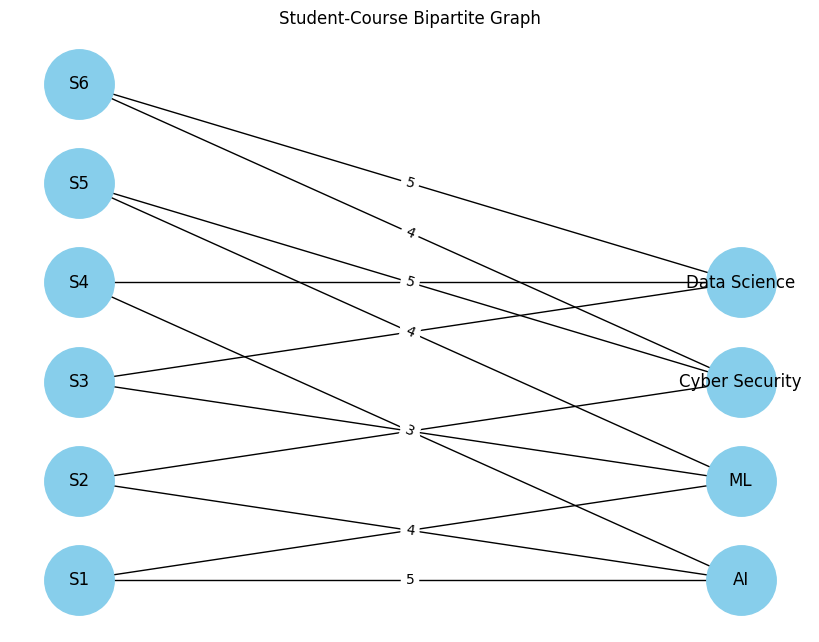

In [3]:
import matplotlib.pyplot as plt

pos = {}

# Students Left
for i, student in enumerate(students):
    pos[student] = (0, i)

# Courses Right
for i, course in enumerate(courses):
    pos[course] = (1, i)

plt.figure(figsize=(8,6))

nx.draw(
    B,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=2500
)

edge_labels = nx.get_edge_attributes(B, "weight")

nx.draw_networkx_edge_labels(
    B,
    pos,
    edge_labels=edge_labels
)

plt.title("Student-Course Bipartite Graph")
plt.show()

**Question 4. Convert into Student-Course Rating Matrix**

In [5]:
matrix = df.pivot_table(
    index="Student",
    columns="Course",
    values="Rating",
    fill_value=0
).astype(int)

print(matrix)

Course   AI  Cyber Security  Data Science  ML
Student                                      
S1        5               0             0   4
S2        4               5             0   0
S3        0               0             4   5
S4        3               0             5   0
S5        0               5             0   4
S6        0               4             5   0


**Question 5. Apply K-Means Clustering**

In [6]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

matrix["Cluster"] = kmeans.fit_predict(matrix)

print(matrix)

Course   AI  Cyber Security  Data Science  ML  Cluster
Student                                               
S1        5               0             0   4        0
S2        4               5             0   0        1
S3        0               0             4   5        0
S4        3               0             5   0        1
S5        0               5             0   4        0
S6        0               4             5   0        1


**Question 6. Draw Clustered Bipartite Graph**

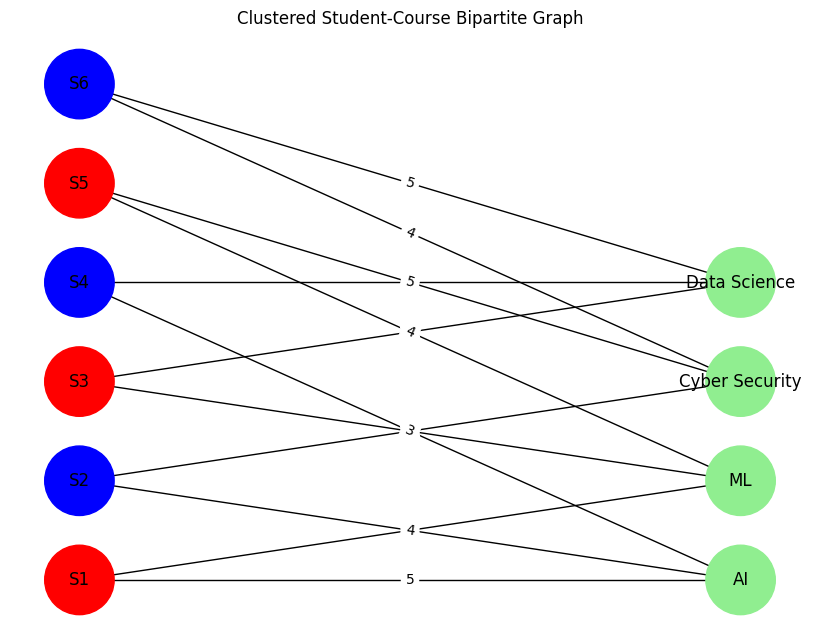

In [7]:
cluster_colors = {
    0: "red",
    1: "blue"
}

colors = []

for node in B.nodes():

    if node in students:
        cluster = matrix.loc[node, "Cluster"]
        colors.append(cluster_colors[cluster])

    else:
        colors.append("lightgreen")

plt.figure(figsize=(8,6))

nx.draw(
    B,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=2500
)

edge_labels = nx.get_edge_attributes(B, "weight")

nx.draw_networkx_edge_labels(
    B,
    pos,
    edge_labels=edge_labels
)

plt.title("Clustered Student-Course Bipartite Graph")

plt.show()

In [8]:
#Cluster table
print(matrix)

Course   AI  Cyber Security  Data Science  ML  Cluster
Student                                               
S1        5               0             0   4        0
S2        4               5             0   0        1
S3        0               0             4   5        0
S4        3               0             5   0        1
S5        0               5             0   4        0
S6        0               4             5   0        1
